# Pagamentos federais em investimentos e inversões financeiras (GND 4 e 5): exploração 2021–2025

### Introdução

O que este trabalho usa são pagamentos do governo federal classificados no orçamento como **grupo 4** (investimentos) ou **grupo 5** (inversões financeiras). Isso vem do critério de natureza da despesa — o tal do GND — dentro do Orçamento Fiscal e da Seguridade Social, só que olhando o governo central. Os dados passam pelo SIAFI e boa parte do que aparece aqui dá para conferir no Portal da Transparência (aquele histórico de gastos diretos / pagamentos).

Na prática: grupo 4 é mais “coisa de obra, equipamento, máquina, material permanente, projeto de sistema quando entra como investimento”. Grupo 5 é outra história — é quando entra capital em empresa, participação societária, ou compra de certos bens já usados; o detalhe certinho está no Manual Técnico de Orçamento e nas regras do sistema, não dá para resumir numa linha só.

Importante: como é base de **pagamento**, estamos falando de dinheiro que efetivamente saiu (caixa), não de empenho nem de “obra concluída”. O restante do notebook é explorar como isso se distribui no tempo, por órgão, função e região.

Este notebook segue a estrutura sugerida no `trabalho-final-projeto-integrado.md`:

1. Definição do problema público  
2. Coleta e preparação dos dados  
3. Análise estatística e exploratória  
4. Storytelling e comunicação dos resultados  
5. Accountability e governança  


---
## 1) Definição do problema público

O recorte do tema já está na introdução. Aqui fica a pergunta que guia a análise e uma justificativa rápida.

**Pergunta (ajuste no PDF se precisar):**

> *Como se distribuem os pagamentos de investimento do governo federal entre períodos, órgãos, funções de governo e regiões entre 2021 e 2025, e o que isso revela sobre priorização orçamentária e transparência da execução?*

**Por que isso importa:** saber onde o dinheiro de fato foi parar ajuda a acompanhar políticas públicas e a cobrar prioridades — não só no papel do orçamento, mas na execução.

Se o trabalho for mais estreito (só uma região, um órgão, ou Fiscal x Seguridade), vale mudar a pergunta para bater com o foco.

---
## 2) Coleta e preparação dos dados

### Bases utilizadas

| Fonte | Conteúdo |
|-------|----------|
| Arquivos `investimentos_2021.csv` … `2024.csv` e `investimentos-2025.xlsx` | Pagamentos (exercício + RP pagos), grupos 4 e 5, governo central |
| Metadados (`metadados-investimentos.pdf`) | Definições de colunas, regime de caixa, periodicidade |

### Preparação (Python)

- Unificação dos anos e padronização de nomes de colunas quando o export 2024/2025 usa cabeçalhos diferentes.  
- Conversão de `movimento_liquido_reais` para `valor_reais` (formato brasileiro no CSV; números já numéricos no Excel).  
- Cache em `data/investimentos_2021_2025.parquet` via `scripts/carregar_investimentos.py`.

### Qualidade e limitações (no PDF você pode colocar números das células abaixo)

- É fluxo de caixa: não é empenho nem “obra entregue”.  
- O PDF de metadados explica o que fica de fora do indicador (ex.: algumas coisas via EOF).  
- Geografia: muita linha sem UF ou município — total por região pode ficar enviesado.

In [9]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "scripts" / "carregar_investimentos.py").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "scripts"))
from carregar_investimentos import carregar_unificado, salvar_parquet

PARQUET = ROOT / "data" / "investimentos_2021_2025.parquet"
if PARQUET.exists():
    df = pd.read_parquet(PARQUET)
    print(f"Carregado: {PARQUET.name} ({len(df):,} linhas)")
else:
    df = carregar_unificado(ROOT, verbose=True)
    salvar_parquet(df, ROOT)

df["ano"] = df["ano"].astype(str)
print("Dimensões:", df.shape)

Carregado: investimentos_2021_2025.parquet (243,259 linhas)
Dimensões: (243259, 29)


In [10]:
# Amostra e tipos
display(df.head(3))
df.info()

,ano,mes,esfera_orcamentaria,esfera_orcamentaria_desc,orgao_maximo,orgao_maximo_desc,uo,uo_desc,grupo_despesa,grupo_despesa_desc,...,programa_desc,acao,acao_desc,regiao,uf,uf_desc,municipio,movimento_liquido_reais,valor_reais,_fonte_arquivo
0,2021,JANEIRO,1,ORCAMENTO FISCAL,1000,CAMARA DOS DEPUTADOS,1101,CAMARA DOS DEPUTADOS,4,INVESTIMENTOS,...,PROGRAMA DE GESTAO E MANUTENCAO DO PODER LEGIS...,4061,"PROCESSO LEGISLATIVO, FISCALIZACAO E REPRESENT...",CENTRO-OESTE,DF,DISTRITO FEDERAL,BRASILIA,"325.437,84",325437.84,investimentos_2021
1,2021,JANEIRO,1,ORCAMENTO FISCAL,2000,SENADO FEDERAL,2101,SENADO FEDERAL,4,INVESTIMENTOS,...,PROGRAMA DE GESTAO E MANUTENCAO DO PODER LEGIS...,4061,"PROCESSO LEGISLATIVO, FISCALIZACAO E REPRESENT...",CENTRO-OESTE,DF,DISTRITO FEDERAL,BRASILIA,"318.392,76",318392.76,investimentos_2021
2,2021,JANEIRO,1,ORCAMENTO FISCAL,2000,SENADO FEDERAL,2101,SENADO FEDERAL,4,INVESTIMENTOS,...,PROGRAMA DE GESTAO E MANUTENCAO DO PODER LEGIS...,2549,COMUNICACAO E DIVULGACAO INSTITUCIONAL,CENTRO-OESTE,DF,DISTRITO FEDERAL,BRASILIA,"3.589,00",3589.00,investimentos_2021


<class 'pandas.DataFrame'>
RangeIndex: 243259 entries, 0 to 243258
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ano                       243259 non-null  str    
 1   mes                       243259 non-null  str    
 2   esfera_orcamentaria       243259 non-null  int64  
 3   esfera_orcamentaria_desc  243259 non-null  str    
 4   orgao_maximo              243259 non-null  int64  
 5   orgao_maximo_desc         243259 non-null  str    
 6   uo                        243259 non-null  int64  
 7   uo_desc                   243259 non-null  str    
 8   grupo_despesa             243259 non-null  int64  
 9   grupo_despesa_desc        243259 non-null  str    
 10  aplicacao                 243259 non-null  int64  
 11  aplicacao_desc            243259 non-null  str    
 12  resultado                 243259 non-null  int64  
 13  resultado_desc            243259 non-null  str    
 14 

In [11]:
# Indicadores de qualidade geográfica (use no relatório)
sem_uf = df["uf_desc"].astype(str).str.upper().str.contains("SEM INFORMACAO", na=False)
sem_mun = df["municipio"].astype(str).str.upper().str.contains("SEM INFORMACAO", na=False)
print(f"Linhas com UF 'sem informação': {sem_uf.mean()*100:.2f}%")
print(f"Linhas com município 'sem informação': {sem_mun.mean()*100:.2f}%")
print(f"Valores ausentes em valor_reais: {df['valor_reais'].isna().sum()}")

Linhas com UF 'sem informação': 29.02%
Linhas com município 'sem informação': 78.58%
Valores ausentes em valor_reais: 0


---
## 3) Análise estatística e exploratória

**O que fazemos nesta seção**

1. **Distribuição dos valores** — média, mediana, percentis e coeficiente de variação: a base tem muitas linhas pequenas e poucas muito grandes (cauda à direita), típico de pagamentos parcelados e grandes contratos.  
2. **Agregação temporal** — totais anuais em bilhões, variação percentual ano a ano e participação do **grupo 4** versus **grupo 5** ao longo do tempo.  
3. **Concentração** — quanto os maiores órgãos explicam do total (Pareto implícito) e um **HHI** simples entre órgãos máximos (soma dos quadrados das participações): leitura qualitativa de dispersão versus concentração.  
4. **Esfera orçamentária e função** — peso Fiscal versus Seguridade e principais funções de governo no volume pago.  
5. **Geografia e co-movimento** — matriz de correlação entre **totais anuais por região** (séries paralelas no tempo). **Correlação não implica causalidade** — regiões podem subir ou cair juntas por ciclo macroeconômico e orçamento federal, não por vínculo direto entre elas.

In [12]:
v = df["valor_reais"]
soma = float(v.sum())
neg_mask = v < 0
pct_neg = 100 * neg_mask.mean()

resumo = pd.Series(
    {
        "n_linhas": len(df),
        "soma_total_R$": soma,
        "media_por_linha_R$": v.mean(),
        "mediana_por_linha_R$": v.median(),
        "desvio_padrao_R$": v.std(),
        "CV_(dp/media)": (v.std() / v.mean()) if v.mean() else float("nan"),
        "min_R$": v.min(),
        "max_R$": v.max(),
        "linhas_com_valor_negativo": int(neg_mask.sum()),
        "pct_linhas_negativas": round(pct_neg, 2),
    }
)
display(resumo)

q = v.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).rename("valor_R$")
display(q.to_frame())

print(
    "\nInsight: mediana << média → cauda pesada (poucos pagamentos muito grandes). "
    f"Linhas com valor negativo (~{pct_neg:.1f}%) costumam refletir estornos/ajustes de caixa no SIAFI."
)

n_linhas                     2.432590e+05
soma_total_R$                3.527567e+11
media_por_linha_R$           1.450128e+06
mediana_por_linha_R$         0.000000e+00
desvio_padrao_R$             3.260637e+07
CV_(dp/media)                2.248517e+01
min_R$                      -3.942227e+08
max_R$                       6.500000e+09
linhas_com_valor_negativo    6.630000e+02
pct_linhas_negativas         2.700000e-01
dtype: float64

,valor_R$
0.10,0.000000e+00
0.25,0.000000e+00
0.50,0.000000e+00
0.75,1.628659e+05
0.90,1.044915e+06
0.99,1.929027e+07



Insight: mediana << média → cauda pesada (poucos pagamentos muito grandes). Linhas com valor negativo (~0.3%) costumam refletir estornos/ajustes de caixa no SIAFI.


In [13]:
# Totais por ano (bilhões R$), variação YoY e % por grupo de despesa (4 vs 5)
tot_ano = df.groupby("ano", dropna=False)["valor_reais"].sum() / 1e9
yoy = (tot_ano.pct_change() * 100).round(2)

_pivot_g = df.pivot_table(
    index="ano", columns="grupo_despesa_desc", values="valor_reais", aggfunc="sum"
)
part_grupo = (_pivot_g.div(_pivot_g.sum(axis=1), axis=0) * 100).round(2)

display(tot_ano.to_frame("bilhoes_R$"))
display(yoy.to_frame("variacao_pct_vs_ano_anterior"))
display(part_grupo)

print(
    "Insight: queda forte 2021→2022 e recuperação seguinte aparecem no fluxo de caixa agregado; "
    "a fatia grupo 4 vs 5 por ano mostra se o período foi mais 'investimento em bens' ou mais 'inversão financeira'."
)

,bilhoes_R$
ano,
2021,56.828236
2022,45.054646
2023,81.365330
2024,86.102105
2025,83.406349


,variacao_pct_vs_ano_anterior
ano,
2021,NaN
2022,-20.72
2023,80.59
2024,5.82
2025,-3.13


grupo_despesa_desc,INVERSOES FINANCEIRAS,INVESTIMENTOS
ano,,
2021,36.62,63.38
2022,9.80,90.20
2023,27.79,72.21
2024,30.17,69.83
2025,16.17,83.83


Insight: queda forte 2021→2022 e recuperação seguinte aparecem no fluxo de caixa agregado; a fatia grupo 4 vs 5 por ano mostra se o período foi mais 'investimento em bens' ou mais 'inversão financeira'.


In [14]:
# Top 15 órgãos (bilhões) + participação no total do período
org_sum = df.groupby("orgao_maximo_desc")["valor_reais"].sum().sort_values(ascending=False)
total_periodo = org_sum.sum()
top15 = org_sum.head(15) / 1e9
share = (org_sum.head(15) / total_periodo * 100).round(2)

tbl = pd.DataFrame({"bilhoes_R$": top15.round(3), "pct_do_total_periodo": share})
display(tbl)

,bilhoes_R$,pct_do_total_periodo
orgao_maximo_desc,,
MINISTERIO DA FAZENDA,57.431,16.28
MINISTERIO DOS TRANSPORTES,55.745,15.80
MINISTERIO DA DEFESA,43.219,12.25
MINIST. DA INTEGR. E DO DESENVOLV. REGIONAL,40.563,11.50
MINISTERIO DAS CIDADES,38.921,11.03
MINISTERIO DA EDUCACAO,34.409,9.75
MINISTERIO DA SAUDE,25.766,7.30
MINISTERIO DA JUSTICA E SEGURANCA PUBLICA,11.972,3.39
MINISTERIO DA AGRICULTURA E PECUARIA,9.273,2.63


In [15]:
# Concentração (HHI / Pareto), esfera orçamentária, funções e região "limpa"
import numpy as np

org_sum = df.groupby("orgao_maximo_desc")["valor_reais"].sum().sort_values(ascending=False)
total = float(org_sum.sum())
shares = org_sum / total
hhi = float((shares**2).sum())
top5_share = float(org_sum.head(5).sum() / total * 100)
top10_share = float(org_sum.head(10).sum() / total * 100)

print("--- Concentração por órgão máximo ---")
print(f"HHI (Σ s²): {hhi:.4f}  → quanto maior, mais concentrado entre poucos órgãos.")
print(f"Top 5 órgãos ≈ {top5_share:.1f}% do valor | Top 10 ≈ {top10_share:.1f}%.\n")

esfera = df.groupby("esfera_orcamentaria_desc", dropna=False)["valor_reais"].sum()
display((esfera / 1e9).round(3).rename("bilhoes_R$").to_frame())
display((esfera / esfera.sum() * 100).round(2).rename("%").to_frame())

func_top = df.groupby("funcao_desc", dropna=False)["valor_reais"].sum().nlargest(8) / 1e9
display(func_top.rename("bilhoes_R$").to_frame())

reg_excl = ["SEM INFORMACAO", "CODIGO INVALIDO", "NACIONAL", "EXTERIOR"]
reg_ok = df[~df["regiao"].isin(reg_excl)].copy()
reg_ano = reg_ok.pivot_table(index="ano", columns="regiao", values="valor_reais", aggfunc="sum") / 1e9
print("Totais anuais por região (bilhões R$), excl. categorias problemáticas:")
display(reg_ano.round(2))

MES_ORD = [
    "JANEIRO", "FEVEREIRO", "MARCO", "ABRIL", "MAIO", "JUNHO",
    "JULHO", "AGOSTO", "SETEMBRO", "OUTUBRO", "NOVEMBRO", "DEZEMBRO",
]
mcat = pd.Categorical(df["mes"], categories=MES_ORD, ordered=True)
mensal = df.assign(_mes=mcat).groupby("_mes", observed=True)["valor_reais"].sum() / 1e9
print("\nPerfil de caixa por mês (soma 2021–2025, bilhões) — picos em dezembro são típicos de fechamento de exercício:")
display(mensal.round(3).rename("bilhoes_R$").to_frame())

--- Concentração por órgão máximo ---
HHI (Σ s²): 0.1095  → quanto maior, mais concentrado entre poucos órgãos.
Top 5 órgãos ≈ 66.9% do valor | Top 10 ≈ 91.7%.



,bilhoes_R$
esfera_orcamentaria_desc,
ORCAMENTO DE SEGURIDADE SOCIAL,33.394
ORCAMENTO FISCAL,319.363


,%
esfera_orcamentaria_desc,
ORCAMENTO DE SEGURIDADE SOCIAL,9.47
ORCAMENTO FISCAL,90.53


,bilhoes_R$
funcao_desc,
ENCARGOS ESPECIAIS,100.079524
TRANSPORTE,55.835524
DEFESA NACIONAL,43.219076
EDUCACAO,34.391734
URBANISMO,28.189424
SAUDE,25.807179
SEGURANCA PUBLICA,12.466657
AGRICULTURA,11.796809


Totais anuais por região (bilhões R$), excl. categorias problemáticas:


regiao,CENTRO-OESTE,NORDESTE,NORTE,SUDESTE,SUL
ano,,,,,
2021,2.25,5.53,3.20,3.24,2.79
2022,2.40,6.08,3.35,3.54,2.68
2023,3.64,9.93,6.25,4.99,5.27
2024,4.01,9.75,6.53,4.47,20.92
2025,3.46,10.58,5.80,4.09,6.13



Perfil de caixa por mês (soma 2021–2025, bilhões) — picos em dezembro são típicos de fechamento de exercício:


,bilhoes_R$
_mes,
JANEIRO,8.306
FEVEREIRO,12.290
MARCO,17.751
ABRIL,20.840
MAIO,26.839
JUNHO,32.730
JULHO,39.725
AGOSTO,24.529
SETEMBRO,26.433


#### Gráfico: correlação entre regiões (heatmap)

**O que é:** cada célula colorida é o coeficiente de **Pearson** entre duas regiões, calculado sobre a **série de totais anuais** (um ponto por ano) de pagamentos GND 4+5, em **R$ milhões**. A tabela numérica acima do gráfico é a mesma matriz.

**Como ler:** tons **avermelhados** (positivos) indicam que, ao longo de 2021–2025, quando o total de uma região sobe em relação à média dos anos, o da outra tende a subir junto; tons **azulados** (negativos) indicam movimento **contrário** entre as séries.

**Interpretação (sem causalidade):** isso mede apenas **co-movimento no tempo** — por exemplo, ciclos macro do orçamento federal, RP ou choques em um ano que afetam várias regiões na mesma direção. **Não** significa que uma região “cause” o fluxo da outra.

**Por que excluímos algumas categorias:** rótulos como `SEM INFORMACAO`, `NACIONAL` ou `CODIGO INVALIDO` geram séries estranhas e correlações espúrias (às vezes ±1). O gráfico usa só **macro-regiões** com geografia mais consistente.

**Limite estatístico:** são **poucos anos**; um exercício atípico muda muito o coeficiente. Use como apoio exploratório no relatório, não como prova definitiva.

regiao,CENTRO-OESTE,NORDESTE,NORTE,SUDESTE,SUL
regiao,,,,,
CENTRO-OESTE,1.000,0.930,0.992,0.886,0.749
NORDESTE,0.930,1.000,0.957,0.842,0.503
NORTE,0.992,0.957,1.000,0.912,0.668
SUDESTE,0.886,0.842,0.912,1.000,0.456
SUL,0.749,0.503,0.668,0.456,1.000


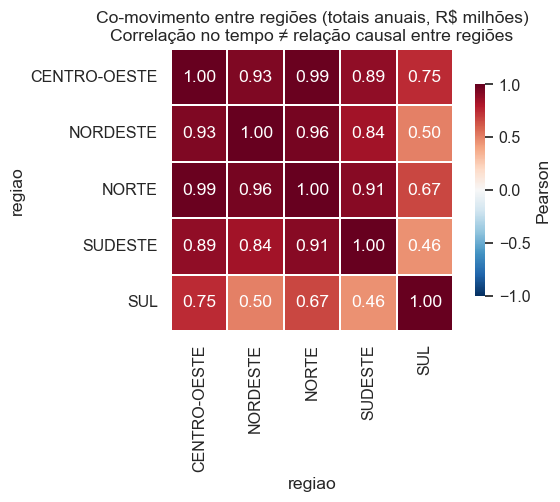

In [20]:
# =============================================================================
# GRÁFICO: correlação entre regiões (tabela + heatmap)
# - Cada valor Pearson compara a série de TOTAIS ANUAIS (2021–2025) entre duas regiões.
# - Interpretação: co-movimento no tempo; NÃO implica causalidade nem "fluxo entre UFs".
# =============================================================================
# Correlação entre regiões (totais anuais em milhões) — só macro-regiões válidas
# (exclui SEM INFORMACAO, NACIONAL etc., que geram correlações espúrias de ±1)
import matplotlib.pyplot as plt
import seaborn as sns

# Regiões excluídas: cadastro "NACIONAL"/"SEM INFO" não representa território homogêneo
reg_excl = ["SEM INFORMACAO", "CODIGO INVALIDO", "NACIONAL", "EXTERIOR"]
reg_df = df[~df["regiao"].isin(reg_excl)].copy()

# Linhas = anos, colunas = região; valores em milhões de reais
pivot_reg = reg_df.pivot_table(
    index="ano", columns="regiao", values="valor_reais", aggfunc="sum"
) / 1e6

# Matriz simétrica: diagonal = 1 (cada região com ela mesma)
corr_reg = pivot_reg.corr().round(3)
display(corr_reg)

# Heatmap: divergindo em zero; anotações mostram o coeficiente em cada célula
fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(
    corr_reg,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.35,
    ax=ax,
    cbar_kws={"shrink": 0.75, "label": "Pearson"},
)
ax.set_title(
    "Co-movimento entre regiões (totais anuais, R$ milhões)\n"
    "Correlação no tempo ≠ relação causal entre regiões"
)
plt.tight_layout()
plt.show()


---
## 4) Storytelling e comunicação dos resultados

**Estrutura:** antes de cada grupo de gráficos há um bloco `####` em markdown com **o que o gráfico mede** e **como interpretar** (e o que *não* concluir). No código, comentários em português repetem eixos, unidades e cuidados metodológicos.

**Leitura dos gráficos abaixo**

- **Evolução anual + YoY:** volume de caixa agregado e a aceleração/desaceleração ano a ano (útil para contextualizar ciclo orçamentário e RP).  
- **Composição 4 vs 5 por ano:** mostra se cada exercício foi mais puxado por **investimento** (bens, obras, equipamentos) ou por **inversão financeira** (capital, participações).  
- **Órgãos e sazonalidade:** quem concentra o fluxo no período e o padrão típico de **dezembro** (fechamento).  
- **Mapa de calor região × ano:** leitura visual da distribuição espacial *após* filtrar categorias geográficas problemáticas.

**Mini-narrativa (para o PDF)**

1. **Contexto:** pagamentos SIAFI em GND 4 e 5 medem caixa executado, não “resultado” de política.  
2. **Tensão analítica:** forte concentração em poucos órgãos e funções de governo versus necessidade de transparência territorial — com limites dos dados (UF/município incompletos).  
3. **Encaminhamento:** dados abertos sustentam controle social e priorização informada; interpretações regionais exigem cautela e outras fontes (população, empenho, obras concluídas).

#### Gráficos 1 e 2: total pago por ano e variação % (YoY)

**Gráfico à esquerda (barras azuis):** para cada ano, a altura é a **soma de todo o caixa** pago naquele exercício, em **bilhões de reais**, incluindo GND 4 e 5. Os **rótulos** em cima das barras servem para citar valores exatos no PDF.

**Gráfico à direita (barras vermelhas):** mostra a **variação percentual** do total em relação ao **ano imediatamente anterior** (YoY). A linha **zero** separa anos em que o agregado **cresceu** ou **diminuiu** em relação ao ano anterior.

**Interpretação:** quedas ou saltos fortes podem refletir **calendário de pagamentos**, **restos a pagar**, mudança na **composição** (mais grupo 4 ou 5) ou efeitos de **reclassificação** — sempre vale cruzar com notas metodológicas e contexto orçamentário, não só com “prioridade política”.

**O que não concluir daqui:** isso **não** mede qualidade de gasto, entrega de obra nem impacto social — apenas **volume de pagamentos** neste recorte.

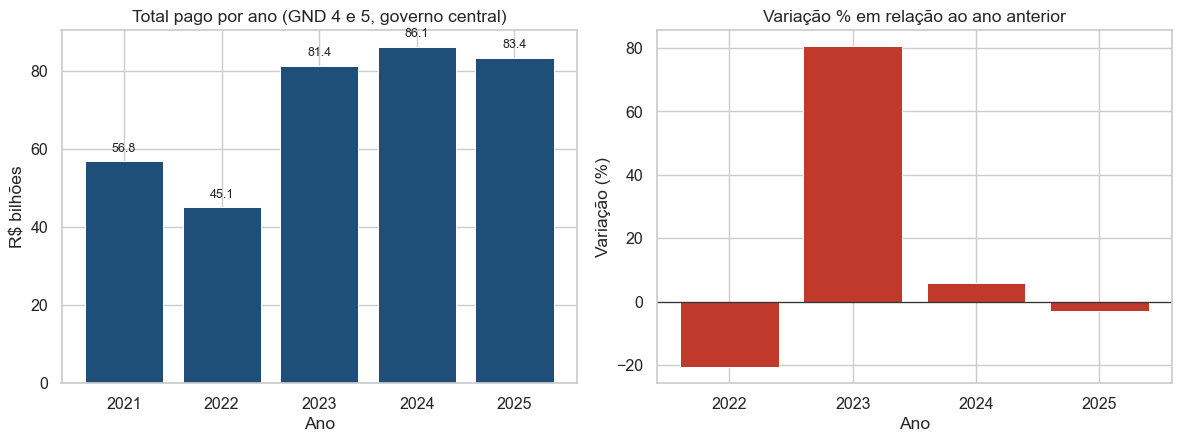

In [21]:
# =============================================================================
# GRÁFICOS 1 e 2: total anual (bilhões) e variação % ano a ano (YoY)
# - Esquerda: NÍVEL do caixa agregado por exercício.
# - Direita: CRESCIMENTO ou QUEDA percentual vs. ano anterior (primeiro ano sem YoY).
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

# Série anual em bilhões de reais (soma de todas as linhas daquele ano)
by_year = df.groupby("ano")["valor_reais"].sum() / 1e9
# Variação percentual; primeiro ano vira NaN e é removido no gráfico da direita
yoy = (by_year.pct_change() * 100).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# --- Painel esquerdo: barras com rótulo do valor exato (bilhões) ---
ax0 = axes[0]
x = by_year.index.astype(str)
ax0.bar(x, by_year.values, color="#1f4e79", edgecolor="white", linewidth=0.7)
ax0.set_title("Total pago por ano (GND 4 e 5, governo central)")
ax0.set_xlabel("Ano")
ax0.set_ylabel("R$ bilhões")
ymax = by_year.max()
for xi, yi in zip(x, by_year.values):
    ax0.text(xi, yi + ymax * 0.02, f"{yi:.1f}", ha="center", va="bottom", fontsize=9, color="#222")

# --- Painel direito: YoY; linha em 0 separa crescimento de queda ---
ax1 = axes[1]
x1 = yoy.index.astype(str)
ax1.bar(x1, yoy.values, color="#c0392b", edgecolor="white", linewidth=0.7)
ax1.axhline(0, color="#333", linewidth=0.9)
ax1.set_title("Variação % em relação ao ano anterior")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Variação (%)")

plt.tight_layout()
plt.show()


#### Gráfico: composição % — grupo 4 (investimentos) vs grupo 5 (inversões financeiras) por ano

**O que é:** gráfico de barras **empilhadas a 100%**. Em cada ano, as duas fatias somam **100%** do total pago naquele exercício. Mostra a **receita relativa** de cada natureza **dentro** do ano, não o volume em bilhões (para absoluto, use o gráfico de totais anuais).

**Como interpretar:** se a fatia do **grupo 5** cresce em determinado ano, aquele exercício ficou **proporcionalmente** mais carregado em pagamentos classificados como **inversão financeira**; se a fatia do **grupo 4** domina, o ano foi mais puxado por **investimento** no sentido orçamentário (bens, obras, equipamentos etc., conforme cadastro).

**Cuidado:** “investimento orçamentário” **não** é o mesmo que “investimento em desenvolvimento econômico” do jornal; os nomes vêm do **GND** e do manual do planejamento.

**Legenda:** textos longos vêm da descrição oficial da despesa; no relatório você pode encurtar para “GND 4” e “GND 5” se definir no texto.

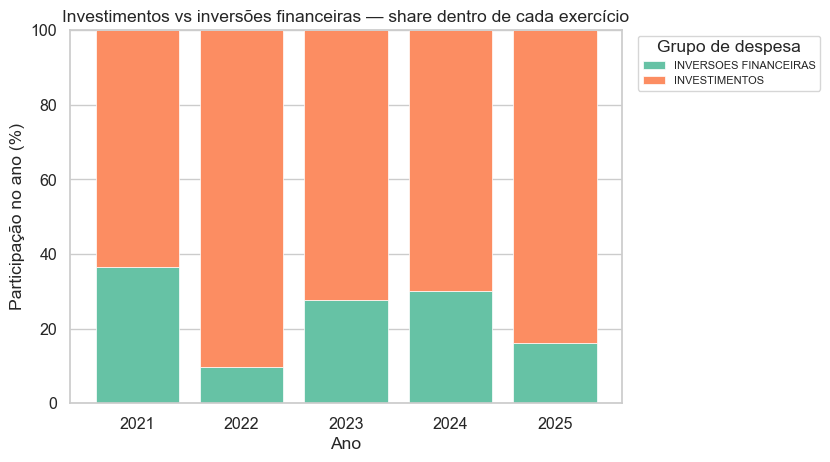

In [22]:
# =============================================================================
# GRÁFICO: composição % dentro de cada ano (GND 4 vs GND 5)
# - Cada coluna empilhada soma 100%: mostra a MISTURA relativa, não o volume absoluto.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Composição grupo 4 vs 5 dentro de cada ano (empilhado 100%)
_pivot_g = df.pivot_table(
    index="ano", columns="grupo_despesa_desc", values="valor_reais", aggfunc="sum"
)
# Percentual do total de cada ano pertencente a cada coluna de grupo_despesa_desc
pct = (_pivot_g.div(_pivot_g.sum(axis=1), axis=0) * 100).sort_index()
cols = list(pct.columns)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bottom = np.zeros(len(pct))
x = pct.index.astype(str)
pal = sns.color_palette("Set2", n_colors=max(len(cols), 3))
for i, c in enumerate(cols):
    lab = str(c)[:48] + ("…" if len(str(c)) > 48 else "")
    vals = pct[c].values
    ax.bar(x, vals, bottom=bottom, label=lab, color=pal[i % len(pal)], edgecolor="white", linewidth=0.5)
    bottom = bottom + vals
ax.set_ylim(0, 100)
ax.set_ylabel("Participação no ano (%)")
ax.set_xlabel("Ano")
ax.set_title("Investimentos vs inversões financeiras — share dentro de cada exercício")
ax.legend(title="Grupo de despesa", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


#### Gráficos seguintes: órgãos, sazonalidade mensal e mapa região × ano

**Primeira figura — painel de cima (12 barras horizontais):** cada barra é a **soma 2021–2025** dos pagamentos para aquele **órgao máximo**. Mede **concentração de fluxo** no período: quem “pesa” mais no caixa agregado. Órgãos com grandes programas de infraestrutura ou equipamentos tendem a aparecer no topo — isso é compatível com a **missão** do órgão, mas **não prova** por si só eficiência ou favoritismo.

**Primeira figura — painel de baixo (12 barras verticais por mês):** soma o caixa de **todos os anos** em cada **mês civil** (janeiro a dezembro). **Picos em dezembro** são comuns no setor público (fechamento de exercício, liquidações). Use para descrever **ritmo de execução**, não “preferência por mês” isolada.

**Segunda figura (mapa de calor):** cada célula é o total **naquele ano** e **naquela região**, em **bilhões**; quanto mais **escuro o azul**, maior o valor. Regiões problemáticas no cadastro foram **excluídas** para leitura mais limpa. Compare **ao longo da linha** (mesma região, anos diferentes) para ver mudança do caixa **neste indicador**.

**Limitações:** totais regionais ainda podem sofrer com **lacunas geográficas** nas linhas micro; evite conclusões territoriais fortes sem cruzar com população, empenho ou outras fontes.

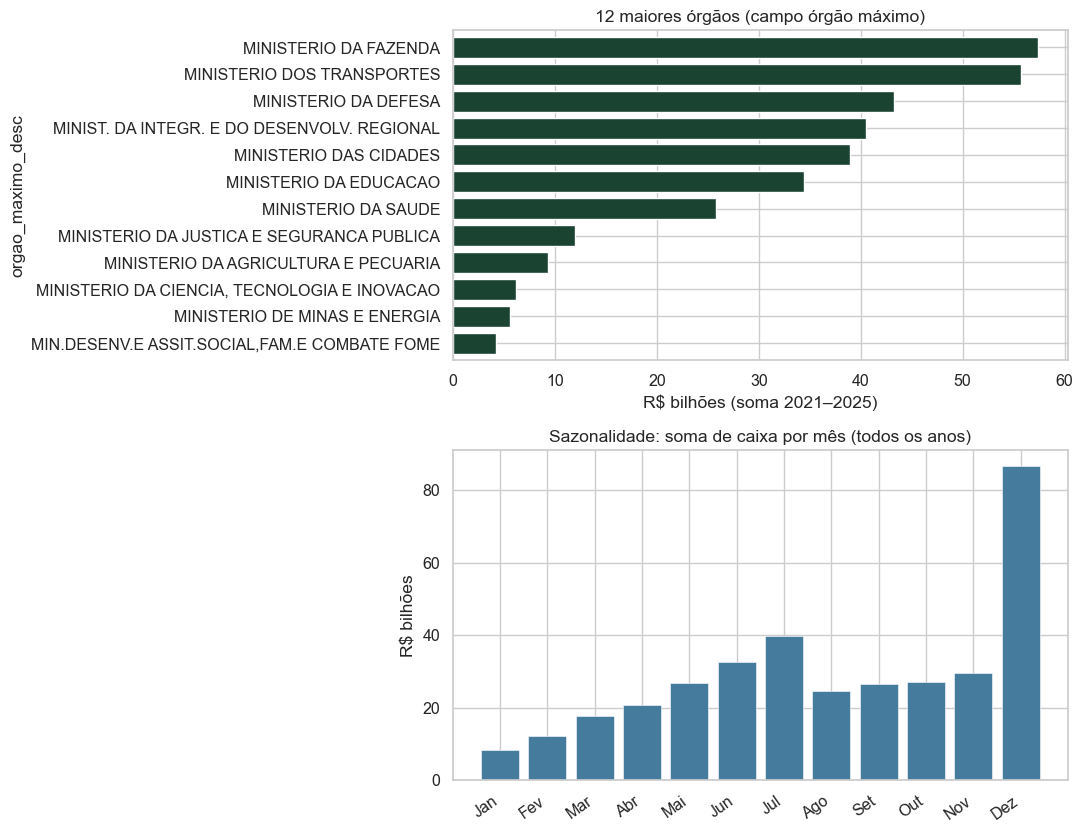

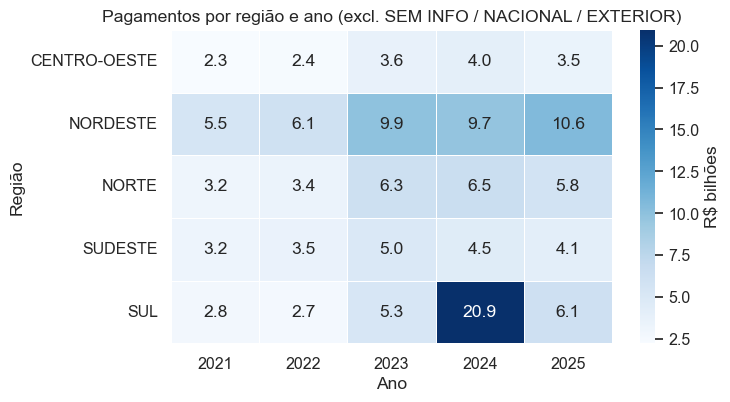

In [23]:
# =============================================================================
# GRÁFICOS: (A) top 12 órgãos + sazonalidade mensal  (B) heatmap região × ano
# - (A) mede concentração institucional e padrão de mês (ex.: dezembro).
# - (B) intensidade = bilhões; mesmas exclusões geográficas que na correlação.
# =============================================================================
# Maiores órgãos + sazonalidade mensal + mapa região × ano (dados filtrados)
import matplotlib.pyplot as plt
import seaborn as sns

MES_ORD = [
    "JANEIRO", "FEVEREIRO", "MARCO", "ABRIL", "MAIO", "JUNHO",
    "JULHO", "AGOSTO", "SETEMBRO", "OUTUBRO", "NOVEMBRO", "DEZEMBRO",
]
# Ordena meses corretamente (ordem alfabética quebraria jan/dez)
mcat = pd.Categorical(df["mes"], categories=MES_ORD, ordered=True)
mensal = df.assign(_mes=mcat).groupby("_mes", observed=True)["valor_reais"].sum() / 1e9

# Soma 2021–2025 por órgão máximo; depois os 12 maiores
top12 = df.groupby("orgao_maximo_desc")["valor_reais"].sum().nlargest(12) / 1e9

reg_excl = ["SEM INFORMACAO", "CODIGO INVALIDO", "NACIONAL", "EXTERIOR"]
reg_ok = df[~df["regiao"].isin(reg_excl)].copy()
# Matriz para heatmap: linha = ano, coluna = região; valores em bilhões
reg_heat = reg_ok.pivot_table(index="ano", columns="regiao", values="valor_reais", aggfunc="sum") / 1e9

# --- Figura A: órgãos (horizontal) + perfil mensal (vertical) ---
fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))

axt = axes[0]
top12.sort_values().plot(kind="barh", ax=axt, color="#1b4332", width=0.78)
axt.set_xlabel("R$ bilhões (soma 2021–2025)")
axt.set_title("12 maiores órgãos (campo órgão máximo)")

axm = axes[1]
axm.bar(range(len(mensal)), mensal.values, color="#457b9d", edgecolor="white", linewidth=0.4)
axm.set_xticks(range(len(mensal)))
axm.set_xticklabels([str(i)[:3].title() for i in mensal.index], rotation=35, ha="right")
axm.set_ylabel("R$ bilhões")
axm.set_title("Sazonalidade: soma de caixa por mês (todos os anos)")

plt.tight_layout()
plt.show()

# --- Figura B: região no eixo Y (transposta) para leitura tipo mapa ---
fig2, axh = plt.subplots(figsize=(7.5, 4.2))
sns.heatmap(
    reg_heat.T,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.4,
    ax=axh,
    cbar_kws={"label": "R$ bilhões"},
)
axh.set_title("Pagamentos por região e ano (excl. SEM INFO / NACIONAL / EXTERIOR)")
axh.set_xlabel("Ano")
axh.set_ylabel("Região")
plt.tight_layout()
plt.show()


---
## 5) Accountability e governança

**Transparência e controle social:** a publicação em dados abertos viabiliza reprodutibilidade da análise e confronto com narrativas institucionais. Atrasos típicos de divulgação (relativos ao RTN) afetam o **timing** do controle.

**Reflexão crítica (elabore no relatório):**

- Implicações **éticas**: evitar conclusões discriminatórias com base só em gasto agregado por UF sem contexto populacional ou histórico de políticas.  
- Implicações **institucionais**: órgãos com maior volume podem concentrar equipamentos e obras por natureza da missão (ex.: infraestrutura), não necessariamente por “preferência” opaca — mas concentração merece escrutínio público.  
- **Limites dos dados:** execução orçamentária não mede qualidade da gestão nem impacto social; complementar com outras fontes quando o trabalho avançar.
